In [6]:
%matplotlib inline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

import numpy as np
import matplotlib.pyplot as plt

In [7]:
batch_size = 32

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=ToTensor())
test_dataset = datasets.MNIST('./data', train=False, transform=ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
for (data, target) in train_loader:
    print('data:', data.size(), 'type:', data.type())
    print('target:', target.size(), 'type:', target.type())
    break

data: torch.Size([32, 1, 28, 28]) type: torch.FloatTensor
target: torch.Size([32]) type: torch.LongTensor


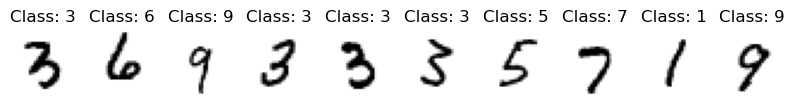

In [9]:
pltsize=1
plt.figure(figsize=(10*pltsize, pltsize))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.axis('off')
    plt.imshow(data[i,:,:,:].numpy().reshape(28,28), cmap="gray_r")
    plt.title('Class: '+str(target[i].item()))

In [24]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer = nn.Linear(in_features=28*28, out_features=64)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(in_features=64, out_features=10)
        self.softmax = nn.Sigmoid()

    def forward(self, x):
        """
        x: [batch_size, 28*28]
        """
        x = self.flatten(x) # [batch_size, 784]
        x = self.layer(x) # [batch_size, 64]
        x = self.relu(x)
        x = self.layer2(x)
        return self.softmax(x)

        

model = SimpleMLP()
print(model)

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer): Linear(in_features=784, out_features=64, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=64, out_features=10, bias=True)
  (softmax): Softmax(dim=None)
)


In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [26]:
def correct(output, target):
    predicted_digits = output.argmax(1)                            # pick digit with largest network output
    correct_ones = (predicted_digits == target).type(torch.float)  # 1.0 for correct, 0.0 for incorrect
    return correct_ones.sum().item()   

In [27]:
for e in range(10):
    for (data, target) in train_loader:
        optimizer.zero_grad()
        # print('data:', data.size(), 'type:', data.type())
        # print('target:', target.size(), 'type:', target.type())
        # data.shape = [32, 1, 28, 28]
        # model: 28*28=784
        output = model(data) 
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(loss)


/var/folders/f7/vcv6y_8x3558nxs233tggpfh0000gp/T/ipykernel_82404/1363261609.py:18: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self.softmax(x)


tensor(2.3010, grad_fn=<NllLossBackward0>)
tensor(2.2950, grad_fn=<NllLossBackward0>)
tensor(2.2939, grad_fn=<NllLossBackward0>)
tensor(2.2846, grad_fn=<NllLossBackward0>)
tensor(2.2797, grad_fn=<NllLossBackward0>)
tensor(2.2860, grad_fn=<NllLossBackward0>)
tensor(2.2650, grad_fn=<NllLossBackward0>)
tensor(2.2087, grad_fn=<NllLossBackward0>)
tensor(2.2048, grad_fn=<NllLossBackward0>)
tensor(2.1979, grad_fn=<NllLossBackward0>)


In [28]:
for (data, target) in test_loader:
    break
print(target)
output = model(data)
print(output)

tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1])
tensor([[0.1092, 0.0369, 0.0424, 0.0451, 0.0965, 0.0431, 0.0485, 0.4358, 0.0630,
         0.0793],
        [0.1375, 0.0738, 0.0901, 0.2594, 0.0476, 0.0570, 0.1631, 0.0456, 0.0841,
         0.0418],
        [0.0691, 0.1566, 0.0797, 0.1232, 0.0880, 0.0754, 0.1082, 0.0986, 0.1127,
         0.0885],
        [0.7776, 0.0070, 0.0148, 0.0400, 0.0147, 0.0135, 0.0480, 0.0590, 0.0149,
         0.0107],
        [0.1409, 0.0349, 0.0700, 0.0729, 0.1862, 0.0484, 0.0975, 0.1935, 0.0689,
         0.0869],
        [0.0578, 0.1796, 0.0705, 0.1469, 0.0832, 0.0724, 0.0897, 0.0984, 0.1133,
         0.0881],
        [0.0541, 0.0532, 0.0620, 0.1071, 0.1742, 0.0546, 0.0791, 0.2192, 0.0908,
         0.1057],
        [0.0522, 0.0837, 0.0600, 0.1452, 0.1397, 0.0605, 0.1055, 0.1383, 0.0970,
         0.1179],
        [0.2478, 0.0417, 0.0778, 0.0671, 0.0979, 0.0529, 0.1711, 0.1217, 0.0608,
         0.061

/var/folders/f7/vcv6y_8x3558nxs233tggpfh0000gp/T/ipykernel_82404/1363261609.py:18: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self.softmax(x)
